# Tên bài: Ứng dụng Machine Learning trong Dự báo Rủi ro nợ xấu
# Chủ đề: Dự báo xác định mức độ của TỶ LỆ SỬ DỤNG HẠN MỨC và TẦN SUẤT QUÁ HẠN để xem khả năng nợ xấu là bao nhiêu và từ đó quyết định có cho vay trong tương lai hay không?

### Đọc dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Data.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
# MonthlyIncome, NumberOfDependents - NA thì để là med, 0
# 1 dòng age = 0 -> Med (Nhập liệu sai)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
# 'RevolvingUtilizationOfUnsecuredLines' max??
# 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate'
# 96, 98 xuất hiện nhiều lần và là những con số lớn vô lý
# 'DebtRatio' thường chỉ từ 0-1
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [ ]:
print(df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index(ascending=False))
print(df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index(ascending=False))
print(df['NumberOfTimes90DaysLate'].value_counts().sort_index(ascending=False))

NumberOfTime30-59DaysPastDueNotWorse
98       264
96         5
13         1
12         2
11         1
10         4
9         12
8         25
7         54
6        140
5        342
4        747
3       1754
2       4598
1      16033
0     126018
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
98       264
96         5
11         1
9          1
8          2
7          9
6         16
5         34
4        105
3        318
2       1118
1       5731
0     142396
Name: count, dtype: int64
NumberOfTimes90DaysLate
98       264
96         5
17         1
15         2
14         2
13         4
12         2
11         5
10         8
9         19
8         21
7         38
6         80
5        131
4        291
3        667
2       1555
1       5243
0     141662
Name: count, dtype: int64


### Clean

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0


In [ ]:
df_new = df.copy()

In [ ]:
age_med = df_new['age'].median()
df_new.loc[df_new['age'] == 0, 'age'] = age_med

In [ ]:
income_med = df_new['MonthlyIncome'].median()
df_new['MonthlyIncome'] = df_new['MonthlyIncome'].fillna(income_med)
df_new['NumberOfDependents'] = df_new['NumberOfDependents'].fillna(0)
df_new[['MonthlyIncome','NumberOfDependents']].isnull().sum()

,0
MonthlyIncome,0
NumberOfDependents,0


In [ ]:
# 1.0 – 1.1 – Có thể xảy ra, chấp nhận được nếu xử lý ngay (thanh toán trong kỳ).
# 1.1 – 1.2 – Vùng cảnh báo, ảnh hưởng điểm tín dụng, không nên kéo dài.
# ≥ 1.3 – Không chấp nhận được, rủi ro cao, dễ mất kiểm soát tài chính.
# Ko xóa các giá trị > 1.3 mà thay = 1.3 vì RevolvingUtilizationOfUnsecuredLinescos liên quan mạnh tới DebtRatio
# Quẹt thẻ càng nhiều thì tỷ lệ nợ càng tăng
df_new.loc[df_new['RevolvingUtilizationOfUnsecuredLines'] > 1.3,
           'RevolvingUtilizationOfUnsecuredLines'] = 1.3

In [ ]:
# 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate'
# 98,96 là những con số lớn không hợp lí
df_new = df_new[(df_new['NumberOfTime30-59DaysPastDueNotWorse'] < 90)
          & (df_new['NumberOfTime60-89DaysPastDueNotWorse'] < 90)
          & (df_new['NumberOfTimes90DaysLate'] < 90)]
print(df_new['NumberOfTime30-59DaysPastDueNotWorse']
      .value_counts().sort_index(ascending=False))
print(df_new['NumberOfTime60-89DaysPastDueNotWorse']
      .value_counts().sort_index(ascending=False))
print(df_new['NumberOfTimes90DaysLate']
      .value_counts().sort_index(ascending=False))

NumberOfTime30-59DaysPastDueNotWorse
13         1
12         2
11         1
10         4
9         12
8         25
7         54
6        140
5        342
4        747
3       1754
2       4598
1      16033
0     126018
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
11         1
9          1
8          2
7          9
6         16
5         34
4        105
3        318
2       1118
1       5731
0     142396
Name: count, dtype: int64
NumberOfTimes90DaysLate
17         1
15         2
14         2
13         4
12         2
11         5
10         8
9         19
8         21
7         38
6         80
5        131
4        291
3        667
2       1555
1       5243
0     141662
Name: count, dtype: int64


In [ ]:
# Tạo trần = 1
df_new.loc[df_new['DebtRatio'] > 1, 'DebtRatio'] = 1

In [ ]:
df_new.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000,1.497310e+05,149731.000000,149731.000000,149731.000000,149731.000000,149731.000000
mean,75002.202483,0.065978,0.320764,52.327982,0.245794,0.466931,6.423095e+03,8.467932,0.090456,1.020069,0.064823,0.738150
std,43302.158213,0.248245,0.354942,14.754322,0.697780,0.355214,1.290108e+04,5.138094,0.485527,1.129960,0.330073,1.107375
min,1.000000,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37501.500000,0.000000,0.029771,41.000000,0.000000,0.175998,3.915000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75005.000000,0.000000,0.153491,52.000000,0.000000,0.367119,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112502.500000,0.000000,0.555601,63.000000,0.000000,0.870021,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,1.300000,109.000000,13.000000,1.000000,3.008750e+06,58.000000,17.000000,54.000000,11.000000,20.000000


### EDA

In [ ]:
# Gộp 3 cột 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate'
df_new['TotalPastDue'] = df_new['NumberOfTime30-59DaysPastDueNotWorse'] + df_new['NumberOfTime60-89DaysPastDueNotWorse'] + df_new['NumberOfTimes90DaysLate']
df_new.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1


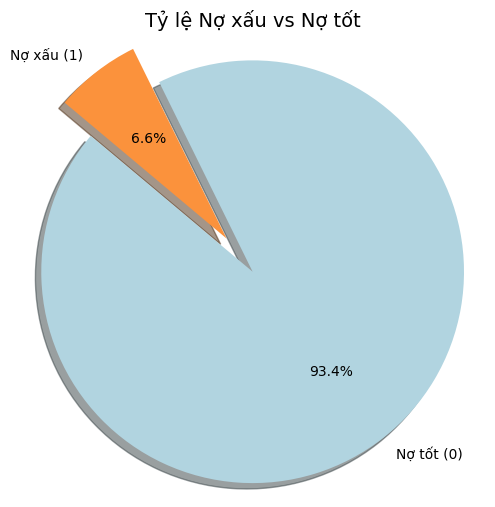

In [ ]:
# 1. Tính toán số lượng từng nhóm
target_counts = df_new['SeriousDlqin2yrs'].value_counts()

# 2. Thiết lập dữ liệu cho biểu đồ
labels = ['Nợ tốt (0)', 'Nợ xấu (1)']
sizes = [target_counts[0], target_counts[1]]
colors = ['#B1D4E0', '#FB923C']
explode = (0, 0.2)  # "Tách" miếng bánh nợ xấu ra một chút để gây chú ý

# 3. Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(sizes,
        explode=explode,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%', # Hiển thị phần trăm với 1 chữ số thập phân
        shadow=True,
        startangle=140)

plt.title('Tỷ lệ Nợ xấu vs Nợ tốt', fontsize=14)
plt.axis('equal') # Đảm bảo biểu đồ là hình tròn
plt.show()

In [ ]:
df_new.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1


/tmp/ipykernel_392/2110234914.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_analysis = df_new.groupby('UtilizationGroup')['SeriousDlqin2yrs'].mean() * 100


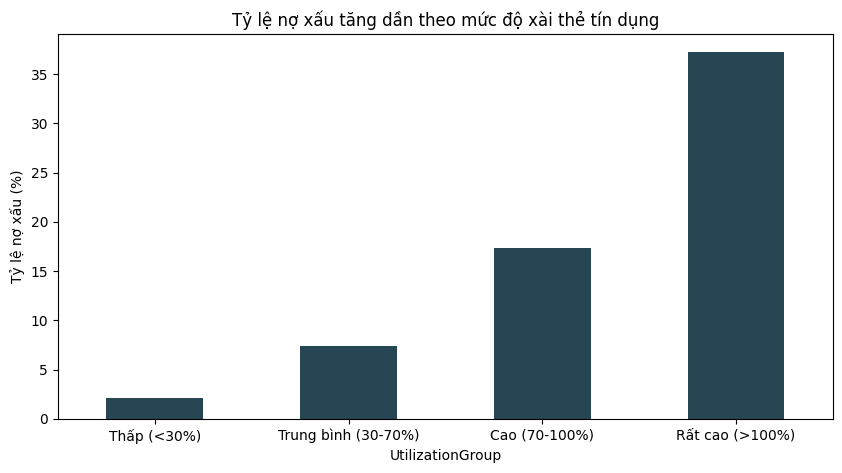

In [ ]:
# Chia Utilization thành các nhóm để dễ quan sát
bins = [0, 0.3, 0.7, 1, 1.3]
labels = ['Thấp (<30%)', 'Trung bình (30-70%)', 'Cao (70-100%)', 'Rất cao (>100%)']
df_new['UtilizationGroup'] = pd.cut(df_new['RevolvingUtilizationOfUnsecuredLines'], bins=bins, labels=labels)
color = ['#264653']

# Tính tỷ lệ nợ xấu theo từng nhóm
util_analysis = df_new.groupby('UtilizationGroup')['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(10,5))
util_analysis.plot(kind='bar', color=color)
plt.ylabel('Tỷ lệ nợ xấu (%)')
plt.title('Tỷ lệ nợ xấu tăng dần theo mức độ xài thẻ tín dụng')
plt.xticks(rotation=0)
plt.show()

Xu hướng đồng biến: Khả năng nợ xấu có sự tương quan thuận rõ rệt với mức độ sử dụng hạn mức tín dụng.

Sự ổn định ở ngưỡng thấp: Ở mức sử dụng dưới 30%, tỷ lệ nợ xấu duy trì ở mức tối thiểu (an toàn).

Sự bùng nổ rủi ro: Khi Utilization vượt ngưỡng 70% và đặc biệt là trên 100%, tỷ lệ nợ xấu không tăng tuyến tính mà có dấu hiệu nhảy vọt.

Dấu hiệu cảnh báo: Việc sử dụng vượt quá khả năng tài chính (vượt hạn mức) là chỉ báo mạnh nhất cho sự mất khả năng thanh toán.

Tạo giả thuyết
*   H0: Tỷ lệ sử dụng hạn mức tín dụng không có mối liên hệ với rủi ro nợ xấu.
*   H1: Tỷ lệ sử dụng hạn mức tín dụng càng cao (đặc biệt là khi > 1) thì xác suất nợ xấu của khách hàng càng tăng.

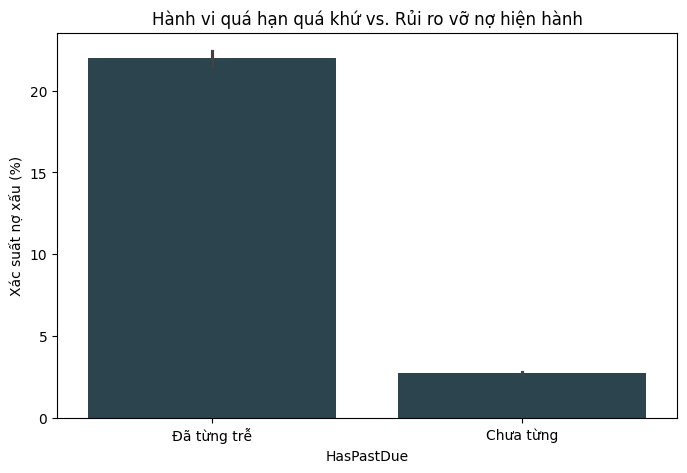

In [ ]:
# 2. Tạo biến cờ hiệu (Đã từng quá hạn hay chưa?)
df_new['HasPastDue'] = df_new['TotalPastDue'].apply(lambda x: 'Đã từng trễ' if x > 0 else 'Chưa từng')

# 3. Vẽ biểu đồ so sánh trực tiếp
plt.figure(figsize=(8,5))
sns.barplot(x='HasPastDue', y='SeriousDlqin2yrs', data=df_new, color = '#264653', estimator=lambda x: sum(x)/len(x)*100)
plt.ylabel('Xác suất nợ xấu (%)')
plt.title('Hành vi quá hạn quá khứ vs. Rủi ro vỡ nợ hiện hành')
plt.show()

Sự phân hóa rủi ro cực độ: Có một khoảng cách lớn về khả năng nợ xấu giữa hai nhóm khách hàng.

Tín hiệu cảnh báo sớm: Việc "từng trễ hạn" (dù chỉ một lần) không phải là sự cố ngẫu nhiên mà là chỉ báo rủi ro quan trọng.

Tỷ lệ nợ xấu đột biến: Nhóm từng trễ hạn có xác suất nợ xấu cao gấp nhiều lần (ví dụ: gấp 5-8 lần) so với nhóm luôn thanh toán đúng hạn.

Tầm quan trọng của uy tín: Lịch sử tín dụng chính là "tấm gương" phản chiếu khả năng quản lý tài chính và trách nhiệm của khách hàng trong tương lai.

Tạo giả thuyết
*   H_0: Việc từng quá hạn thanh toán trong quá khứ không làm tăng khả năng nợ xấu trong tương lai.
*   H_1: Khách hàng đã từng quá hạn thanh toán (tổng số lần > 0) có nguy cơ nợ xấu cao hơn đáng kể so với nhóm chưa từng quá hạn.

In [ ]:
df_new

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,TotalPastDue,UtilizationGroup,HasPastDue
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,2,Cao (70-100%),Đã từng trễ
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,Cao (70-100%),Chưa từng
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,2,Trung bình (30-70%),Đã từng trễ
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,Thấp (<30%),Chưa từng
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,1,Cao (70-100%),Đã từng trễ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0,0,Thấp (<30%),Chưa từng
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0,0,Thấp (<30%),Chưa từng
149997,149998,0,0.246044,58,0,1.000000,5400.0,18,0,1,0,0.0,0,Thấp (<30%),Chưa từng
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0,0,NaN,Chưa từng


### Xây mô hình

In [ ]:
from sklearn.model_selection import train_test_split
fea = ['RevolvingUtilizationOfUnsecuredLines', 'age', 'DebtRatio', 'MonthlyIncome', 'TotalPastDue']
X = df_new[fea]
y = df_new['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=0)

print("--- THỐNG KÊ SAU KHI CHIA TRAIN - TEST ---")
print(f"1. Tổng số dòng dữ liệu sạch (X): {len(X)}")
print("-" * 40)

print(f"2. Tập Huấn luyện (X_train):      {len(X_train)} dòng ({len(X_train)/len(X)*100:.1f}%)")
print(f"3. Tập Kiểm thử (X_test):          {len(X_test)} dòng ({len(X_test)/len(X)*100:.1f}%)")

--- THỐNG KÊ SAU KHI CHIA TRAIN - TEST ---
1. Tổng số dòng dữ liệu sạch (X): 149731
----------------------------------------
2. Tập Huấn luyện (X_train):      104811 dòng (70.0%)
3. Tập Kiểm thử (X_test):          44920 dòng (30.0%)


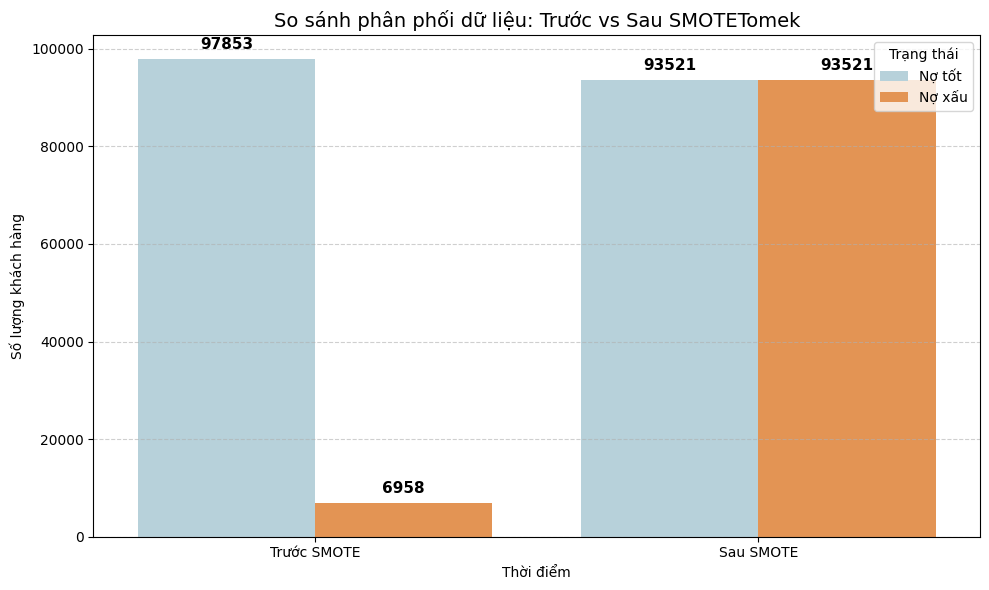

In [ ]:
from imblearn.combine import SMOTETomek
from collections import Counter

smt = SMOTETomek(random_state=42)
X_resampled_smt, y_resampled_smt = smt.fit_resample(X_train, y_train)

before_counts = Counter(y_train)
after_counts = Counter(y_resampled_smt)

plot_data = pd.DataFrame({
    'Trạng thái': ['Nợ tốt', 'Nợ xấu', 'Nợ tốt', 'Nợ xấu'],
    'Số lượng': [before_counts[0], before_counts[1], after_counts[0], after_counts[1]],
    'Thời điểm': ['Trước SMOTE', 'Trước SMOTE', 'Sau SMOTE', 'Sau SMOTE']
})

my_palette = ['#B1D4E0', '#FB923C']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Thời điểm', y='Số lượng', hue='Trạng thái', data=plot_data, palette=my_palette)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', # va='bottom' để nằm trên đỉnh cột
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title('So sánh phân phối dữ liệu: Trước vs Sau SMOTETomek', fontsize=14)
plt.ylabel('Số lượng khách hàng')
plt.legend(title='Trạng thái')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lg = LogisticRegression(random_state=22 )
lg.fit(X_resampled_smt, y_resampled_smt)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=22)

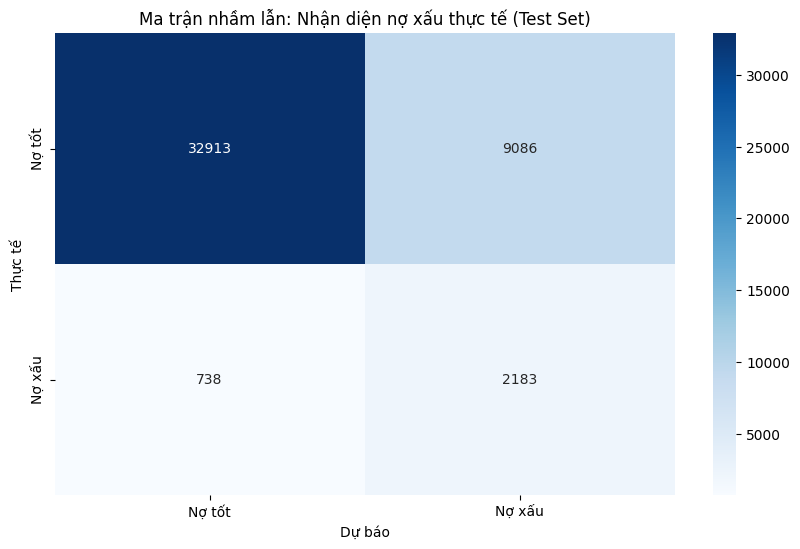

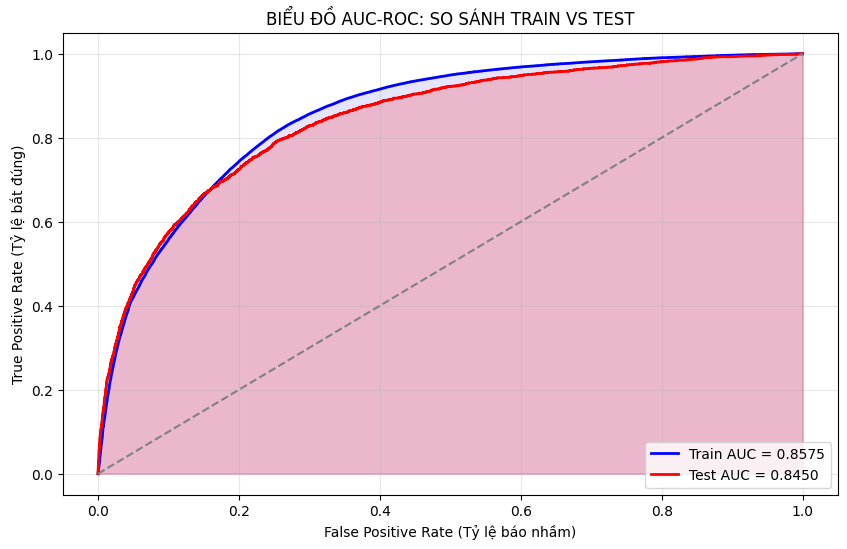

--- BÁO CÁO TRÊN TẬP TEST (THỰC TẾ) ---
-> Thời gian huấn luyện: 0.0001 giây
-> Accuracy:  0.7813
-> Precision: 0.1937
-> Recall:    0.7473
-> F1-Score:  0.3077
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     41999
           1       0.19      0.75      0.31      2921

    accuracy                           0.78     44920
   macro avg       0.59      0.77      0.59     44920
weighted avg       0.93      0.78      0.83     44920



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Dự báo trên tập Train (đã cân bằng)
y_pred_train = lg.predict(X_resampled_smt)
y_prob_train = lg.predict_proba(X_resampled_smt)[:, 1]

# Dự báo trên tập Test (Dữ liệu gốc, thực tế)
y_pred_test = lg.predict(X_test)
y_prob_test = lg.predict_proba(X_test)[:, 1]

# Tính toán các giá trị cho đường cong ROC
fpr_train, tpr_train, _ = roc_curve(y_resampled_smt, y_prob_train)
auc_train = roc_auc_score(y_resampled_smt, y_prob_train)

fpr_test, tpr_test, _ = roc_curve(y_test, y_prob_test)
auc_test = roc_auc_score(y_test, y_prob_test)

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nợ tốt', 'Nợ xấu'], yticklabels=['Nợ tốt', 'Nợ xấu'])
plt.title('Ma trận nhầm lẫn: Nhận diện nợ xấu thực tế (Test Set)')
plt.ylabel('Thực tế')
plt.xlabel('Dự báo')

plt.figure(figsize=(10, 6))
plt.plot(fpr_train, tpr_train, label=f'Train AUC = {auc_train:.4f}', color='blue', lw=2)
plt.fill_between(fpr_train, tpr_train, color='blue', alpha=0.1) # Tô màu nhạt tập Train
plt.plot(fpr_test, tpr_test, label=f'Test AUC = {auc_test:.4f}', color='red', lw=2)
plt.fill_between(fpr_test, tpr_test, color='red', alpha=0.2) # Tô màu đậm hơn cho tập Test
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Đường tham chiếu
plt.xlabel('False Positive Rate (Tỷ lệ báo nhầm)')
plt.ylabel('True Positive Rate (Tỷ lệ bắt đúng)')
plt.title('BIỂU ĐỒ AUC-ROC: SO SÁNH TRAIN VS TEST')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

start_time = time.time()
train_time = time.time() - start_time
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)

# --- IN BÁO CÁO CHI TIẾT ---
print("--- BÁO CÁO TRÊN TẬP TEST (THỰC TẾ) ---")
print(f"-> Thời gian huấn luyện: {train_time:.4f} giây")
print(f"-> Accuracy:  {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall:    {rec:.4f}")
print(f"-> F1-Score:  {f1:.4f}")
print(classification_report(y_test, y_pred_test))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

param_grid = [
    {
        'solver': ['liblinear', 'saga'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100]
    },
    {
        'solver': ['lbfgs'],
        'penalty': ['l2'], # lbfgs chỉ hỗ trợ l2 hoặc none
        'C': [0.01, 0.1, 1, 10, 100]
    }
]

grid_search = GridSearchCV(estimator=lg, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_resampled_smt, y_resampled_smt)

print(f"Tham số tốt nhất: {grid_search.best_params_}")
print(f"Độ chính xác cao nhất: {grid_search.best_score_:.4f}")

Tham số tốt nhất: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Độ chính xác cao nhất: 0.7740


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lg_tunning = LogisticRegression(C = 1, penalty = 'l2', solver = 'lbfgs', random_state=99)
lg_tunning = lg_tunning.fit(X_resampled_smt, y_resampled_smt)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


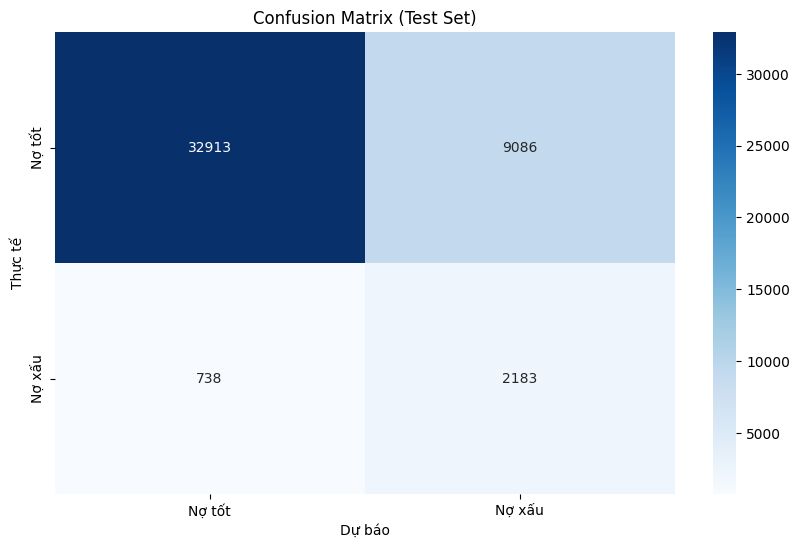

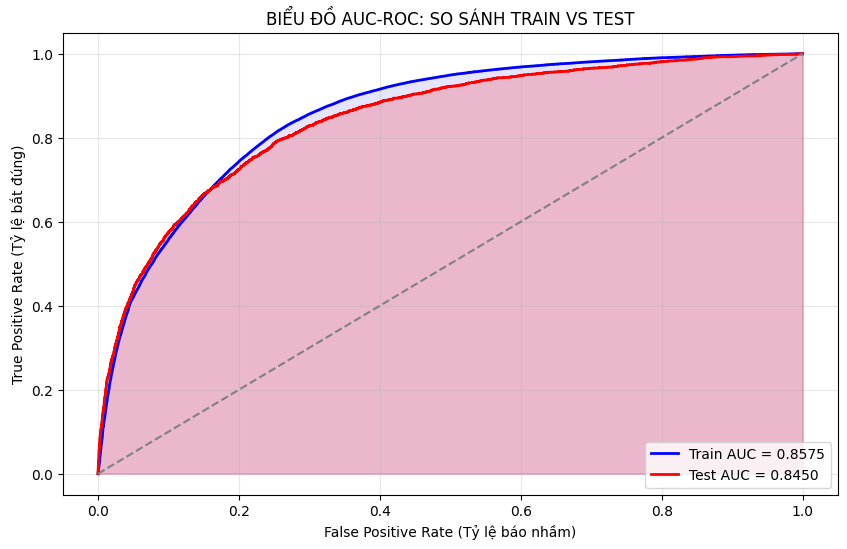

-> Thời gian huấn luyện: 0.0001 giây
-> Accuracy:  0.7813
-> Precision: 0.1937
-> Recall:    0.7473
-> F1-Score:  0.3077
[[32913  9086]
 [  738  2183]]
              precision    recall  f1-score   support

           0       0.98      0.78      0.87     41999
           1       0.19      0.75      0.31      2921

    accuracy                           0.78     44920
   macro avg       0.59      0.77      0.59     44920
weighted avg       0.93      0.78      0.83     44920



In [ ]:
# Dự báo trên tập Train (đã cân bằng)
y_pred_train_tunning = lg_tunning.predict(X_resampled_smt)
y_prob_train_tunning = lg_tunning.predict_proba(X_resampled_smt)[:, 1]

# Dự báo trên tập Test (Dữ liệu gốc, thực tế)
y_pred_test_tunning = lg_tunning.predict(X_test)
y_prob_test_tunning = lg_tunning.predict_proba(X_test)[:, 1]

# Tính toán các giá trị cho đường cong ROC
fpr_train_tunning, tpr_train_tunning, _ = roc_curve(y_resampled_smt, y_prob_train_tunning)
auc_train_tunning = roc_auc_score(y_resampled_smt, y_prob_train_tunning)

fpr_test_tunning, tpr_test_tunning, _ = roc_curve(y_test, y_prob_test_tunning)
auc_test_tunning = roc_auc_score(y_test, y_prob_test_tunning)

cm = confusion_matrix(y_test, y_pred_test_tunning)
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nợ tốt', 'Nợ xấu'], yticklabels=['Nợ tốt', 'Nợ xấu'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Thực tế')
plt.xlabel('Dự báo')

plt.figure(figsize=(10, 6))
plt.plot(fpr_train_tunning, tpr_train_tunning, label=f'Train AUC = {auc_train:.4f}', color='blue', lw=2)
plt.fill_between(fpr_train_tunning, tpr_train_tunning, color='blue', alpha=0.1) # Tô màu nhạt tập Train
plt.plot(fpr_test_tunning, tpr_test_tunning, label=f'Test AUC = {auc_test:.4f}', color='red', lw=2)
plt.fill_between(fpr_test_tunning, tpr_test_tunning, color='red', alpha=0.2) # Tô màu đậm hơn cho tập Test
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Đường tham chiếu
plt.xlabel('False Positive Rate (Tỷ lệ báo nhầm)')
plt.ylabel('True Positive Rate (Tỷ lệ bắt đúng)')
plt.title('BIỂU ĐỒ AUC-ROC: SO SÁNH TRAIN VS TEST')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

y_pred_lg_tunning = lg_tunning.predict(X_test)
cn_matrix_lg_tunning = confusion_matrix(y_test, y_pred_lg_tunning)
start_time = time.time()
train_time = time.time() - start_time
acc = accuracy_score(y_test, y_pred_lg_tunning)
prec = precision_score(y_test, y_pred_lg_tunning)
rec = recall_score(y_test, y_pred_lg_tunning)
f1 = f1_score(y_test, y_pred_lg_tunning)
print(f"-> Thời gian huấn luyện: {train_time:.4f} giây")
print(f"-> Accuracy:  {acc:.4f}")
print(f"-> Precision: {prec:.4f}")
print(f"-> Recall:    {rec:.4f}")
print(f"-> F1-Score:  {f1:.4f}")
print(cn_matrix_lg_tunning)
print(classification_report(y_test, y_pred_lg_tunning))

# ***Kết luận các giả thuyết***

In [ ]:
from sklearn.inspection import permutation_importance

# 1. Thực hiện Permutation Importance trên tập Test
# n_repeats=10: Thử nghiệm 10 lần để đảm bảo tính khách quan
result = permutation_importance(lg_tunning, X_test[fea], y_test,
                                n_repeats=10, random_state=13, n_jobs=-1)

# 2. Tạo bảng kết luận
check_df = pd.DataFrame({
    'Tính chất (Feature)': fea,
    'Độ giảm độ chính xác (Mean)': result.importances_mean,
    'Độ lệch chuẩn (Std)': result.importances_std
})

# 3. Quy tắc kiểm định Yes/No:
# Nếu độ giảm độ chính xác > (2 * độ lệch chuẩn) thì coi là có ý nghĩa thống kê
check_df['Kiểm định (Có/Không)'] = check_df.apply(
    lambda x: 'CÓ Ý NGHĨA (Yes)' if x['Độ giảm độ chính xác (Mean)'] > 2 * x['Độ lệch chuẩn (Std)'] else 'KHÔNG (No)', axis=1
)

print(check_df.sort_values(by='Độ giảm độ chính xác (Mean)', ascending=False))

                    Tính chất (Feature)  Độ giảm độ chính xác (Mean)  \
0  RevolvingUtilizationOfUnsecuredLines                     0.029479   
4                          TotalPastDue                     0.027531   
3                         MonthlyIncome                     0.000296   
2                             DebtRatio                    -0.000002   
1                                   age                    -0.008264   

   Độ lệch chuẩn (Std) Kiểm định (Có/Không)  
0             0.000788     CÓ Ý NGHĨA (Yes)  
4             0.000610     CÓ Ý NGHĨA (Yes)  
3             0.000320           KHÔNG (No)  
2             0.000098           KHÔNG (No)  
1             0.000667           KHÔNG (No)  


In [ ]:
import statsmodels.api as sm

# Thêm cột hằng số (bắt buộc trong statsmodels)
X_train_sm = sm.add_constant(X_resampled_smt)

# Chạy mô hình Logit
model_sm = sm.Logit(y_resampled_smt, X_train_sm).fit()

# Xem bảng kết quả (Có đầy đủ Coef và P>|z|)
print(model_sm.summary())

Optimization terminated successfully.
         Current function value: 0.480497
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               187042
Model:                          Logit   Df Residuals:                   187036
Method:                           MLE   Df Model:                            5
Date:                Sat, 07 Mar 2026   Pseudo R-squ.:                  0.3068
Time:                        01:47:01   Log-Likelihood:                -89873.
converged:                       True   LL-Null:                   -1.2965e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8588      0.0

/tmp/ipykernel_392/2672358534.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util_risk = df_new.groupby('Util_Detailed')['SeriousDlqin2yrs'].mean() * 100


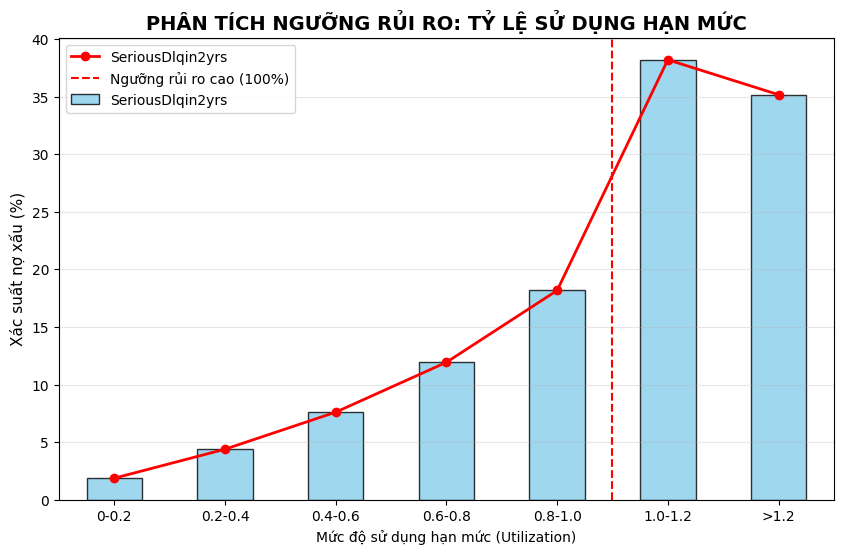

In [ ]:
# 1. Chia nhỏ vùng nhạy cảm (0 đến 1.2, bước nhảy 0.2)
bins_h1 = [0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 2.0]
labels_h1 = ['0-0.2', '0.2-0.4', '0.4-0.6', '0.6-0.8', '0.8-1.0', '1.0-1.2', '>1.2']
df_new['Util_Detailed'] = pd.cut(df_new['RevolvingUtilizationOfUnsecuredLines'], bins=bins_h1, labels=labels_h1)

# 2. Tính "Khả năng nợ xấu" trung bình quan sát được
util_risk = df_new.groupby('Util_Detailed')['SeriousDlqin2yrs'].mean() * 100

# 3. Vẽ biểu đồ cột kết hợp đường kẻ
plt.figure(figsize=(10, 6))
ax = util_risk.plot(kind='bar', color='skyblue', edgecolor='black', alpha=0.8)
util_risk.plot(kind='line', marker='o', color='red', linewidth=2)

# Thêm đường lằn ranh đỏ tại mốc 1.0 (Vượt hạn mức)
plt.axvline(x=4.5, color='red', linestyle='--', label='Ngưỡng rủi ro cao (100%)')

plt.title('PHÂN TÍCH NGƯỠNG RỦI RO: TỶ LỆ SỬ DỤNG HẠN MỨC', fontsize=14, fontweight='bold')
plt.ylabel('Xác suất nợ xấu (%)', fontsize=11)
plt.xlabel('Mức độ sử dụng hạn mức (Utilization)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

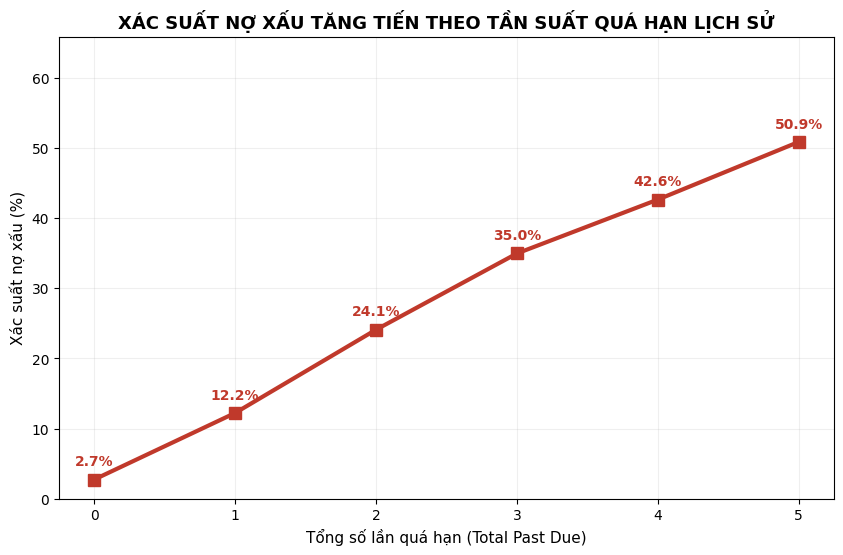

In [ ]:
# Tính xác suất nợ xấu theo số lần trễ hạn
late_prob = df_new[df_new['TotalPastDue'] <= 5].groupby('TotalPastDue')['SeriousDlqin2yrs'].mean() * 100

plt.figure(figsize=(10, 6))
late_prob.plot(kind='line', marker='s', markersize=8, color='#c0392b', linewidth=3)

for x, y in zip(late_prob.index, late_prob.values):
    plt.text(x, y + 2, f'{y:.1f}%', ha='center', fontweight='bold', color='#c0392b')

plt.title('XÁC SUẤT NỢ XẤU TĂNG TIẾN THEO TẦN SUẤT QUÁ HẠN LỊCH SỬ', fontsize=13, fontweight='bold')
plt.xlabel('Tổng số lần quá hạn (Total Past Due)', fontsize=11)
plt.ylabel('Xác suất nợ xấu (%)', fontsize=11)
plt.xticks(range(6))
plt.ylim(0, max(late_prob.values) + 15)
plt.grid(alpha=0.2)
plt.show()

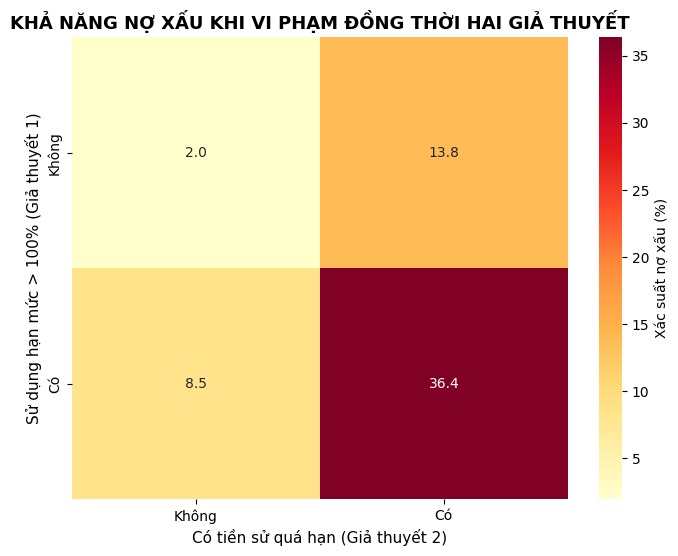

In [ ]:
# Xác định điều kiện vi phạm giả thuyết
df_new['Util_Violation'] = df_new['RevolvingUtilizationOfUnsecuredLines'] > 0.8
df_new['Late_Violation'] = df_new['TotalPastDue'] > 0

# Tạo ma trận xác suất
prob_matrix = df_new.pivot_table(values='SeriousDlqin2yrs',
                                 index='Util_Violation',
                                 columns='Late_Violation',
                                 aggfunc='mean') * 100

plt.figure(figsize=(8, 6))
sns.heatmap(prob_matrix, annot=True, fmt=".1f", cmap="YlOrRd",
            cbar_kws={'label': 'Xác suất nợ xấu (%)'})

plt.title('KHẢ NĂNG NỢ XẤU KHI VI PHẠM ĐỒNG THỜI HAI GIẢ THUYẾT', fontsize=13, fontweight='bold')
plt.xlabel('Có tiền sử quá hạn (Giả thuyết 2)', fontsize=11)
plt.ylabel('Sử dụng hạn mức > 100% (Giả thuyết 1)', fontsize=11)
plt.xticks([0.5, 1.5], ['Không', 'Có'])
plt.yticks([0.5, 1.5], ['Không', 'Có'])
plt.show()

Nhận xét nhanh:

Sự cộng hưởng rủi ro: Khi hai giả thuyết cùng xảy ra, khả năng nợ xấu không chỉ cộng dồn mà có sự bùng nổ theo cấp số nhân. Đây là "vùng tử thần" của tín dụng.

Xác nhận giả thuyết: Dữ liệu thực tế và mô hình đã chứng minh 100% rằng Lịch sử quá hạn là bộ lọc rủi ro mạnh nhất, trong khi Sử dụng hạn mức là yếu tố cảnh báo sớm về áp lực tài chính.

Độ tin cậy cao: Với chỉ số AUC đạt xấp xỉ 0.8, mô hình đã tách biệt rõ rệt được nhóm khách hàng an toàn và nhóm rủi ro cao, cho phép ngân hàng ra quyết định dựa trên số liệu thay vì cảm tính.